# Rainfall prediction ML model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/weather_rainfall_prediction.csv")

In [3]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2010-04-30,Adelaide,10.8,21.2,0.0,1.8,6.60,ENE,22.0,ENE,...,66.0,48.0,1028.4,1024.7,4.45,4.51,15.7,21.0,No,No
1,2014-07-22,Adelaide,3.7,19.0,0.0,1.4,7.61,N,24.0,N,...,75.0,32.0,1024.2,1021.1,4.45,4.51,9.6,18.5,No,No
2,2014-07-23,Adelaide,9.6,15.8,0.0,2.6,7.61,NE,52.0,NNE,...,35.0,51.0,1017.9,1011.5,4.45,4.51,14.7,15.4,No,Yes
3,2014-07-24,Adelaide,10.1,15.5,16.6,0.8,7.61,NNE,50.0,NW,...,96.0,80.0,1007.4,1008.0,4.45,4.51,11.2,14.0,Yes,Yes
4,2014-07-25,Adelaide,11.2,16.2,1.8,0.6,7.61,NW,30.0,WNW,...,89.0,70.0,1018.4,1019.2,4.45,4.51,13.0,15.3,Yes,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        145460 non-null  float64
 3   MaxTemp        145460 non-null  float64
 4   Rainfall       145460 non-null  float64
 5   Evaporation    145460 non-null  float64
 6   Sunshine       145460 non-null  float64
 7   WindGustDir    145460 non-null  object 
 8   WindGustSpeed  145460 non-null  float64
 9   WindDir9am     145460 non-null  object 
 10  WindDir3pm     145460 non-null  object 
 11  WindSpeed9am   145460 non-null  float64
 12  WindSpeed3pm   145460 non-null  float64
 13  Humidity9am    145460 non-null  float64
 14  Humidity3pm    145460 non-null  float64
 15  Pressure9am    145460 non-null  float64
 16  Pressure3pm    145460 non-null  float64
 17  Cloud9am       145460 non-nul

In [5]:
df.shape

(145460, 23)

In [6]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000
mean,12.193993,23.221337,2.360898,5.468995,7.610612,40.035567,14.043384,18.662601,68.880816,51.539143,1017.649946,1015.256314,4.448437,4.509959,16.990624,21.683306
std,6.365750,7.088124,8.382488,3.161541,2.729486,13.118253,8.861059,8.716581,18.854765,20.471189,6.728467,6.663973,2.265605,2.092954,6.449221,6.850057
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000
25%,7.700000,18.000000,0.000000,4.000000,7.610000,31.000000,7.000000,13.000000,57.000000,37.000000,1013.500000,1011.100000,3.000000,4.000000,12.300000,16.700000
50%,12.100000,22.700000,0.000000,5.470000,7.610000,39.000000,13.000000,18.660000,69.000000,51.540000,1017.650000,1015.260000,4.450000,4.510000,16.800000,21.400000
75%,16.800000,28.200000,1.000000,5.470000,8.700000,46.000000,19.000000,24.000000,83.000000,65.000000,1021.800000,1019.400000,6.000000,6.000000,21.500000,26.200000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000


In [7]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

## Analysis and next process

Our dataset have `(145460 rows and 23 columns)` and we have zero null values which is a plus point. 
Now our target variable is **`RainTomorrow`** we can also chose `RainToday` but `RainTomorrow` goes more with idea and data.
Now to reduce some complexity we will drop some columns which are not contrubating in our model. And we will combine some columns to reduce it's size, like `Pressure_mean = (Pressure9am + Pressure3pm) / 2` and `Pressure_diff = Pressure3pm − Pressure9am`.

In [8]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

In [9]:
# combine preasure meas & prassure difference
df['Pressure_mean'] = (df['Pressure9am'] + df['Pressure3pm'])/2
df['Pressure_diff'] = df['Pressure3pm'] - df['Pressure9am']

In [10]:
# combination of WindDir
df['WindSpeed_mean'] = (df['WindSpeed9am'] + df['WindSpeed3pm'])/2
df['WindSpeed_diff'] = df['WindSpeed3pm'] - df['WindSpeed9am']

In [11]:
# combination of Humidity
df['Humidity_mean'] = (df['Humidity9am'] + df['Humidity3pm'])/2
df['Humidity_diff'] = df['Humidity3pm'] - df['Humidity9am']

In [12]:
# combination of cloud
df['Cloud_mean'] = (df['Cloud9am'] + df['Cloud3pm'])/2
df['Cloud_diff'] = df['Cloud3pm'] - df['Cloud9am']

In [13]:
# combination of Temp
df['Temp_range'] = (df['Temp9am'] + df['Temp3pm'])/2
df['Temp_diff'] = df['Temp3pm'] - df['Temp9am']

In [14]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow', 'Pressure_mean',
       'Pressure_diff', 'WindSpeed_mean', 'WindSpeed_diff', 'Humidity_mean',
       'Humidity_diff', 'Cloud_mean', 'Cloud_diff', 'Temp_range', 'Temp_diff'],
      dtype='object')

Extracting some useful data form `Date` feature

In [15]:
df['Date'] = pd.to_datetime(df['Date'])

In [16]:
# month
df['Month'] = df['Date'].dt.month

In [17]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Pressure_diff,WindSpeed_mean,WindSpeed_diff,Humidity_mean,Humidity_diff,Cloud_mean,Cloud_diff,Temp_range,Temp_diff,Month
0,2010-04-30,Adelaide,10.8,21.2,0.0,1.8,6.60,ENE,22.0,ENE,...,-3.7,8.0,-2.0,57.0,-18.0,4.48,0.06,18.35,5.3,4
1,2014-07-22,Adelaide,3.7,19.0,0.0,1.4,7.61,N,24.0,N,...,-3.1,5.5,11.0,53.5,-43.0,4.48,0.06,14.05,8.9,7
2,2014-07-23,Adelaide,9.6,15.8,0.0,2.6,7.61,NE,52.0,NNE,...,-6.4,14.5,11.0,43.0,16.0,4.48,0.06,15.05,0.7,7
3,2014-07-24,Adelaide,10.1,15.5,16.6,0.8,7.61,NNE,50.0,NW,...,0.6,21.5,9.0,88.0,-16.0,4.48,0.06,12.60,2.8,7
4,2014-07-25,Adelaide,11.2,16.2,1.8,0.6,7.61,NW,30.0,WNW,...,0.8,14.0,2.0,79.5,-19.0,4.48,0.06,14.15,2.3,7


In [18]:
df.drop(columns=['Date', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday'], inplace=True)

In [19]:
df.shape

(145460, 22)

In [20]:
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Pressure_diff,WindSpeed_mean,WindSpeed_diff,Humidity_mean,Humidity_diff,Cloud_mean,Cloud_diff,Temp_range,Temp_diff,Month
0,Adelaide,10.8,21.2,0.0,1.8,6.60,ENE,22.0,ENE,NW,...,-3.7,8.0,-2.0,57.0,-18.0,4.48,0.06,18.35,5.3,4
1,Adelaide,3.7,19.0,0.0,1.4,7.61,N,24.0,N,NNE,...,-3.1,5.5,11.0,53.5,-43.0,4.48,0.06,14.05,8.9,7
2,Adelaide,9.6,15.8,0.0,2.6,7.61,NE,52.0,NNE,NE,...,-6.4,14.5,11.0,43.0,16.0,4.48,0.06,15.05,0.7,7
3,Adelaide,10.1,15.5,16.6,0.8,7.61,NNE,50.0,NW,NW,...,0.6,21.5,9.0,88.0,-16.0,4.48,0.06,12.60,2.8,7
4,Adelaide,11.2,16.2,1.8,0.6,7.61,NW,30.0,WNW,WNW,...,0.8,14.0,2.0,79.5,-19.0,4.48,0.06,14.15,2.3,7


In [21]:
df['WindDir9am'].value_counts()

WindDir9am
N      22324
SE      9287
E       9176
SSE     9112
NW      8749
S       8659
W       8459
SW      8423
NNE     8129
NNW     7980
ENE     7836
NE      7671
ESE     7630
SSW     7587
WNW     7414
WSW     7024
Name: count, dtype: int64

In [22]:
df['WindDir3pm'].value_counts()

WindDir3pm
SE     15066
W      10110
S       9926
WSW     9518
SSE     9399
SW      9354
N       8890
WNW     8874
NW      8610
ESE     8505
E       8472
NE      8263
SSW     8156
NNW     7870
ENE     7857
NNE     6590
Name: count, dtype: int64

In [23]:
# Converting direction into angle

direction_map = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
}

df['WindDir9am_angle'] = df['WindDir9am'].map(direction_map)
df['WindDir3pm_angle'] = df['WindDir3pm'].map(direction_map)

In [24]:
df['WindGustDir_angle'] = df['WindGustDir'].map(direction_map)

In [25]:
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity_mean,Humidity_diff,Cloud_mean,Cloud_diff,Temp_range,Temp_diff,Month,WindDir9am_angle,WindDir3pm_angle,WindGustDir_angle
0,Adelaide,10.8,21.2,0.0,1.8,6.60,ENE,22.0,ENE,NW,...,57.0,-18.0,4.48,0.06,18.35,5.3,4,67.5,315.0,67.5
1,Adelaide,3.7,19.0,0.0,1.4,7.61,N,24.0,N,NNE,...,53.5,-43.0,4.48,0.06,14.05,8.9,7,0.0,22.5,0.0
2,Adelaide,9.6,15.8,0.0,2.6,7.61,NE,52.0,NNE,NE,...,43.0,16.0,4.48,0.06,15.05,0.7,7,22.5,45.0,45.0
3,Adelaide,10.1,15.5,16.6,0.8,7.61,NNE,50.0,NW,NW,...,88.0,-16.0,4.48,0.06,12.60,2.8,7,315.0,315.0,22.5
4,Adelaide,11.2,16.2,1.8,0.6,7.61,NW,30.0,WNW,WNW,...,79.5,-19.0,4.48,0.06,14.15,2.3,7,292.5,292.5,315.0


In [26]:
df.drop(columns=['WindDir9am', 'WindDir3pm', 'WindGustDir'], inplace = True)

In [27]:
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,RainTomorrow,Pressure_mean,Pressure_diff,...,Humidity_mean,Humidity_diff,Cloud_mean,Cloud_diff,Temp_range,Temp_diff,Month,WindDir9am_angle,WindDir3pm_angle,WindGustDir_angle
0,Adelaide,10.8,21.2,0.0,1.8,6.60,22.0,No,1026.55,-3.7,...,57.0,-18.0,4.48,0.06,18.35,5.3,4,67.5,315.0,67.5
1,Adelaide,3.7,19.0,0.0,1.4,7.61,24.0,No,1022.65,-3.1,...,53.5,-43.0,4.48,0.06,14.05,8.9,7,0.0,22.5,0.0
2,Adelaide,9.6,15.8,0.0,2.6,7.61,52.0,Yes,1014.70,-6.4,...,43.0,16.0,4.48,0.06,15.05,0.7,7,22.5,45.0,45.0
3,Adelaide,10.1,15.5,16.6,0.8,7.61,50.0,Yes,1007.70,0.6,...,88.0,-16.0,4.48,0.06,12.60,2.8,7,315.0,315.0,22.5
4,Adelaide,11.2,16.2,1.8,0.6,7.61,30.0,Yes,1018.80,0.8,...,79.5,-19.0,4.48,0.06,14.15,2.3,7,292.5,292.5,315.0


## Insights

We combined and created some new featuers based on existing once and deleted `droped` existing. Our traget variable `RainTomorrow` is a categorical variable which we will encode uning `LabelEncoder` and other featuers also where it is needed.

---

In [28]:
df['Location'].unique().sum()

'AdelaideAlbanyAlburyAliceSpringsBadgerysCreekBallaratBendigoBrisbaneCairnsCanberraCobarCoffsHarbourDartmoorDarwinGoldCoastHobartKatherineLauncestonMelbourneMelbourneAirportMilduraMoreeMountGambierMountGininiNewcastleNhilNorahHeadNorfolkIslandNuriootpaPearceRAAFPenrithPerthPerthAirportPortlandRichmondSaleSalmonGumsSydneySydneyAirportTownsvilleTuggeranongUluruWaggaWaggaWalpoleWatsoniaWilliamtownWitchcliffeWollongongWoomera'

In [29]:
df['Location'].nunique()

49

Now lets map location based on their group.

In [30]:
climate_map = {
     # Newly added
    'BadgerysCreek': 'Coastal',
    'Mildura': 'Arid',

    # Tropical (hot, humid, monsoon)
    'Darwin': 'Tropical',
    'Cairns': 'Tropical',
    'Townsville': 'Tropical',
    'Katherine': 'Tropical',

    # Arid / Desert
    'AliceSprings': 'Arid',
    'Uluru': 'Arid',
    'Woomera': 'Arid',
    'Cobar': 'Arid',

    # Temperate (cooler southern regions)
    'Melbourne': 'Temperate',
    'MelbourneAirport': 'Temperate',
    'Hobart': 'Temperate',
    'Launceston': 'Temperate',
    'Ballarat': 'Temperate',
    'Bendigo': 'Temperate',
    'Sale': 'Temperate',
    'Watsonia': 'Temperate',
    'WaggaWagga': 'Temperate',
    'MountGambier': 'Temperate',
    'Portland': 'Temperate',

    # Coastal Humid (east coast rain-influenced)
    'Sydney': 'Coastal',
    'SydneyAirport': 'Coastal',
    'Newcastle': 'Coastal',
    'Wollongong': 'Coastal',
    'Brisbane': 'Coastal',
    'GoldCoast': 'Coastal',
    'CoffsHarbour': 'Coastal',
    'NorahHead': 'Coastal',
    'Williamtown': 'Coastal',

    # Mediterranean / West Coast
    'Perth': 'Mediterranean',
    'PerthAirport': 'Mediterranean',
    'PearceRAAF': 'Mediterranean',
    'Albany': 'Mediterranean',
    'Walpole': 'Mediterranean',
    'Witchcliffe': 'Mediterranean',
    'SalmonGums': 'Mediterranean',
    'Nuriootpa': 'Mediterranean',

    # Alpine / Highlands
    'MountGinini': 'Alpine',
    'Canberra': 'Alpine',
    'Tuggeranong': 'Alpine',

    # Special / Island
    'NorfolkIsland': 'Coastal',

    # Remaining inland / mixed
    'Adelaide': 'Temperate',
    'Penrith': 'Coastal',
    'Richmond': 'Coastal',
    'Nhil': 'Temperate',
    'Moree': 'Arid',
    'Albury': 'Temperate',
    'Dartmoor': 'Temperate'
}


In [31]:
df['ClimateZone'] = df['Location'].map(climate_map)

In [32]:
df['ClimateZone'].value_counts()

ClimateZone
Temperate        44411
Coastal          39753
Mediterranean    24276
Arid             16654
Tropical         10851
Alpine            9515
Name: count, dtype: int64

In [33]:
df['Location'].value_counts().sum()

145460

In [34]:
df.drop(columns=['Location'], inplace=True)

In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['ClimateZone'] = le.fit_transform(df['ClimateZone'])
df['RainTomorrow'] = le.fit_transform(df['RainTomorrow'])

In [36]:
# df['RainTomorrow'] = df['RainTomorrow'].astype(int)
df['RainTomorrow'].value_counts()

RainTomorrow
0    113583
1     31877
Name: count, dtype: int64

In [37]:
df.head(20)

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,RainTomorrow,Pressure_mean,Pressure_diff,WindSpeed_mean,...,Humidity_diff,Cloud_mean,Cloud_diff,Temp_range,Temp_diff,Month,WindDir9am_angle,WindDir3pm_angle,WindGustDir_angle,ClimateZone
0,10.8,21.2,0.0,1.80,6.60,22.0,0,1026.55,-3.7,8.0,...,-18.0,4.48,0.06,18.35,5.3,4,67.5,315.0,67.5,4
1,3.7,19.0,0.0,1.40,7.61,24.0,0,1022.65,-3.1,5.5,...,-43.0,4.48,0.06,14.05,8.9,7,0.0,22.5,0.0,4
2,9.6,15.8,0.0,2.60,7.61,52.0,1,1014.70,-6.4,14.5,...,16.0,4.48,0.06,15.05,0.7,7,22.5,45.0,45.0,4
3,10.1,15.5,16.6,0.80,7.61,50.0,1,1007.70,0.6,21.5,...,-16.0,4.48,0.06,12.60,2.8,7,315.0,315.0,22.5,4
4,11.2,16.2,1.8,0.60,7.61,30.0,1,1018.80,0.8,14.0,...,-19.0,4.48,0.06,14.15,2.3,7,292.5,292.5,315.0,4
5,10.3,16.2,3.0,5.47,7.61,22.0,0,1027.15,-2.1,11.0,...,-40.0,4.48,0.06,13.05,5.3,7,0.0,337.5,337.5,4
6,6.4,17.4,0.0,5.47,7.61,43.0,0,1022.40,-4.8,13.0,...,-10.0,4.48,0.06,14.35,4.3,7,0.0,337.5,0.0,4
7,9.9,16.7,0.0,3.80,7.61,37.0,0,1017.80,-2.6,15.0,...,3.0,4.48,0.06,14.05,4.1,7,0.0,315.0,315.0,4
8,9.1,16.9,0.0,0.80,7.61,50.0,1,1016.60,-0.6,18.0,...,-6.0,4.48,0.06,14.05,2.7,7,337.5,315.0,315.0,4
9,12.7,17.3,3.2,0.40,7.61,43.0,0,1017.20,-3.2,17.5,...,-15.0,4.48,0.06,14.90,2.8,7,315.0,315.0,337.5,4


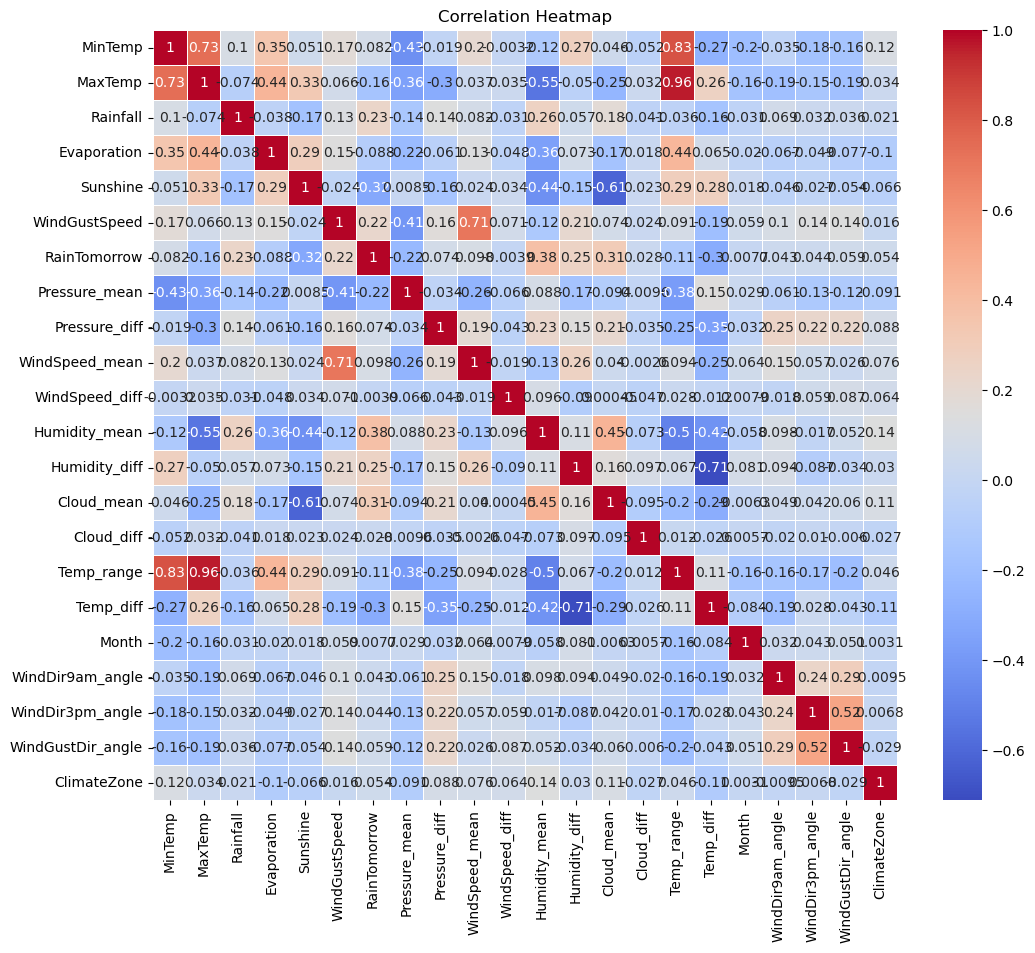

In [38]:
plt.figure(figsize=(12, 10))

corr = df.corr()
sns.heatmap(corr, 
            annot=True,      # True will print numbers (can get messy)
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

In [39]:
import math

def plot_boxplots(df, columns, n_cols=2):
    '''Plots box plots'''
    n_rows = math.ceil(len(columns) / n_cols)
    plt.figure(figsize=(12, 4 * n_rows))
    
    for i, col in enumerate(columns, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.boxplot(x=df[col])
        plt.title(col)
    
    plt.tight_layout()
    plt.show()

In [40]:
df.columns

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'RainTomorrow', 'Pressure_mean', 'Pressure_diff',
       'WindSpeed_mean', 'WindSpeed_diff', 'Humidity_mean', 'Humidity_diff',
       'Cloud_mean', 'Cloud_diff', 'Temp_range', 'Temp_diff', 'Month',
       'WindDir9am_angle', 'WindDir3pm_angle', 'WindGustDir_angle',
       'ClimateZone'],
      dtype='object')

In [41]:
cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'Pressure_mean', 'Pressure_diff',
       'WindSpeed_mean', 'WindSpeed_diff', 'Humidity_mean', 'Humidity_diff',
       'Cloud_mean', 'Cloud_diff', 'Temp_range', 'Temp_diff']

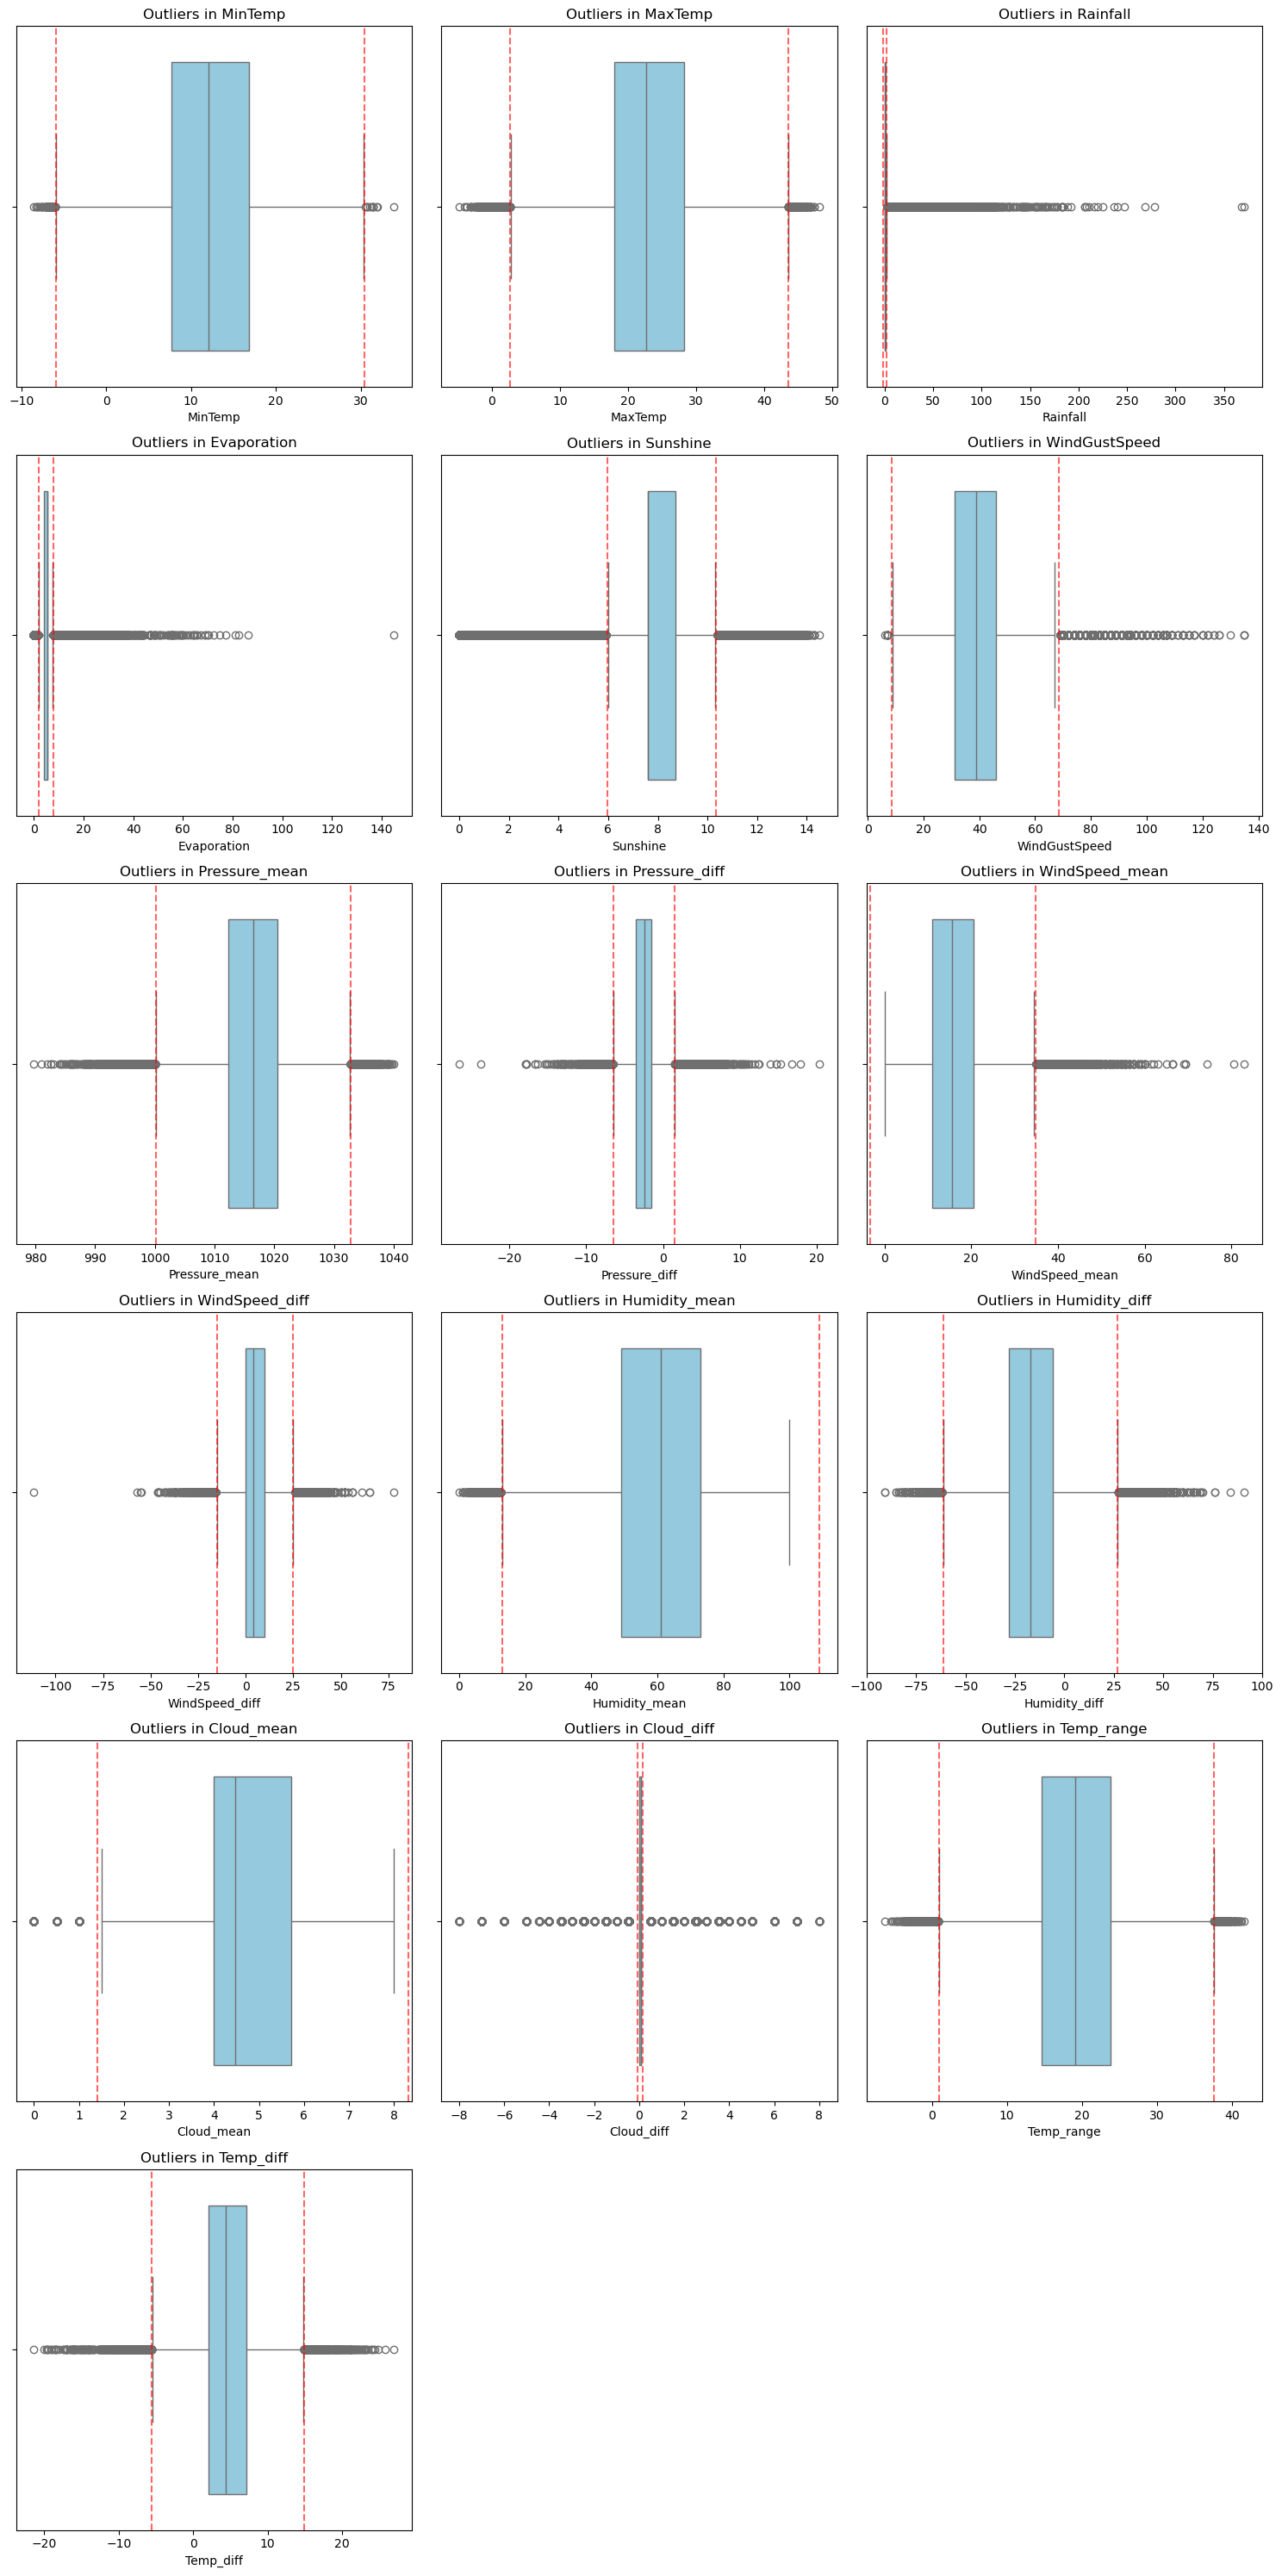

In [42]:
from outliers import OutlierDetector

detector = OutlierDetector(df)
limits = detector.find_fences(columns=cols, plot=True)

In [43]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,RainTomorrow,Pressure_mean,Pressure_diff,WindSpeed_mean,...,Humidity_diff,Cloud_mean,Cloud_diff,Temp_range,Temp_diff,Month,WindDir9am_angle,WindDir3pm_angle,WindGustDir_angle,ClimateZone
count,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.00000,145460.000000,145460.000000,...,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000
mean,12.193993,23.221337,2.360898,5.468995,7.610612,40.035567,0.219146,1016.45313,-2.393632,16.352993,...,-17.341673,4.479198,0.061522,19.336965,4.692682,6.399615,151.659838,171.017788,177.002733,2.755995
std,6.365750,7.088124,8.382488,3.161541,2.729486,13.118253,0.413669,6.62835,1.903030,7.642891,...,16.303238,1.924989,2.050490,6.388980,3.708798,3.427262,109.756267,99.677741,100.584931,1.365342
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,979.75000,-26.550000,0.000000,...,-91.000000,0.000000,-8.000000,-6.300000,-21.390000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,7.700000,18.000000,0.000000,4.000000,7.610000,31.000000,0.000000,1012.35000,-3.500000,11.000000,...,-28.000000,4.000000,0.000000,14.650000,2.100000,3.000000,45.000000,90.000000,90.000000,2.000000
50%,12.100000,22.700000,0.000000,5.470000,7.610000,39.000000,0.000000,1016.45500,-2.400000,15.500000,...,-17.000000,4.480000,0.060000,19.050000,4.400000,6.000000,157.500000,157.500000,180.000000,3.000000
75%,16.800000,28.200000,1.000000,5.470000,8.700000,46.000000,0.000000,1020.50000,-1.500000,20.500000,...,-6.000000,5.725000,0.060000,23.800000,7.200000,9.000000,247.500000,247.500000,270.000000,4.000000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,1.000000,1040.05000,20.360000,83.000000,...,91.000000,8.000000,8.000000,41.600000,26.980000,12.000000,337.500000,337.500000,337.500000,5.000000


In [44]:
df['Humidity_mean'].min()

0.0

In [45]:
(df['Temp_range']<0).value_counts()

Temp_range
False    145230
True        230
Name: count, dtype: int64

In [46]:
df = df[df['Temp_range'] >= 0]

In [47]:
df.shape

(145230, 22)

In [48]:
df['Evaporation'].describe()

count    145230.000000
mean          5.468993
std           3.164044
min           0.000000
25%           4.000000
50%           5.470000
75%           5.470000
max         145.000000
Name: Evaporation, dtype: float64

In [49]:
(df['Evaporation']> 60).value_counts()

Evaporation
False    145208
True         22
Name: count, dtype: int64

In [50]:
df['Evaporation'].quantile(0.99)

15.8

In [51]:
upper = df['Evaporation'].quantile(0.99)
df['Evaporation'] = df['Evaporation'].clip(upper=upper)

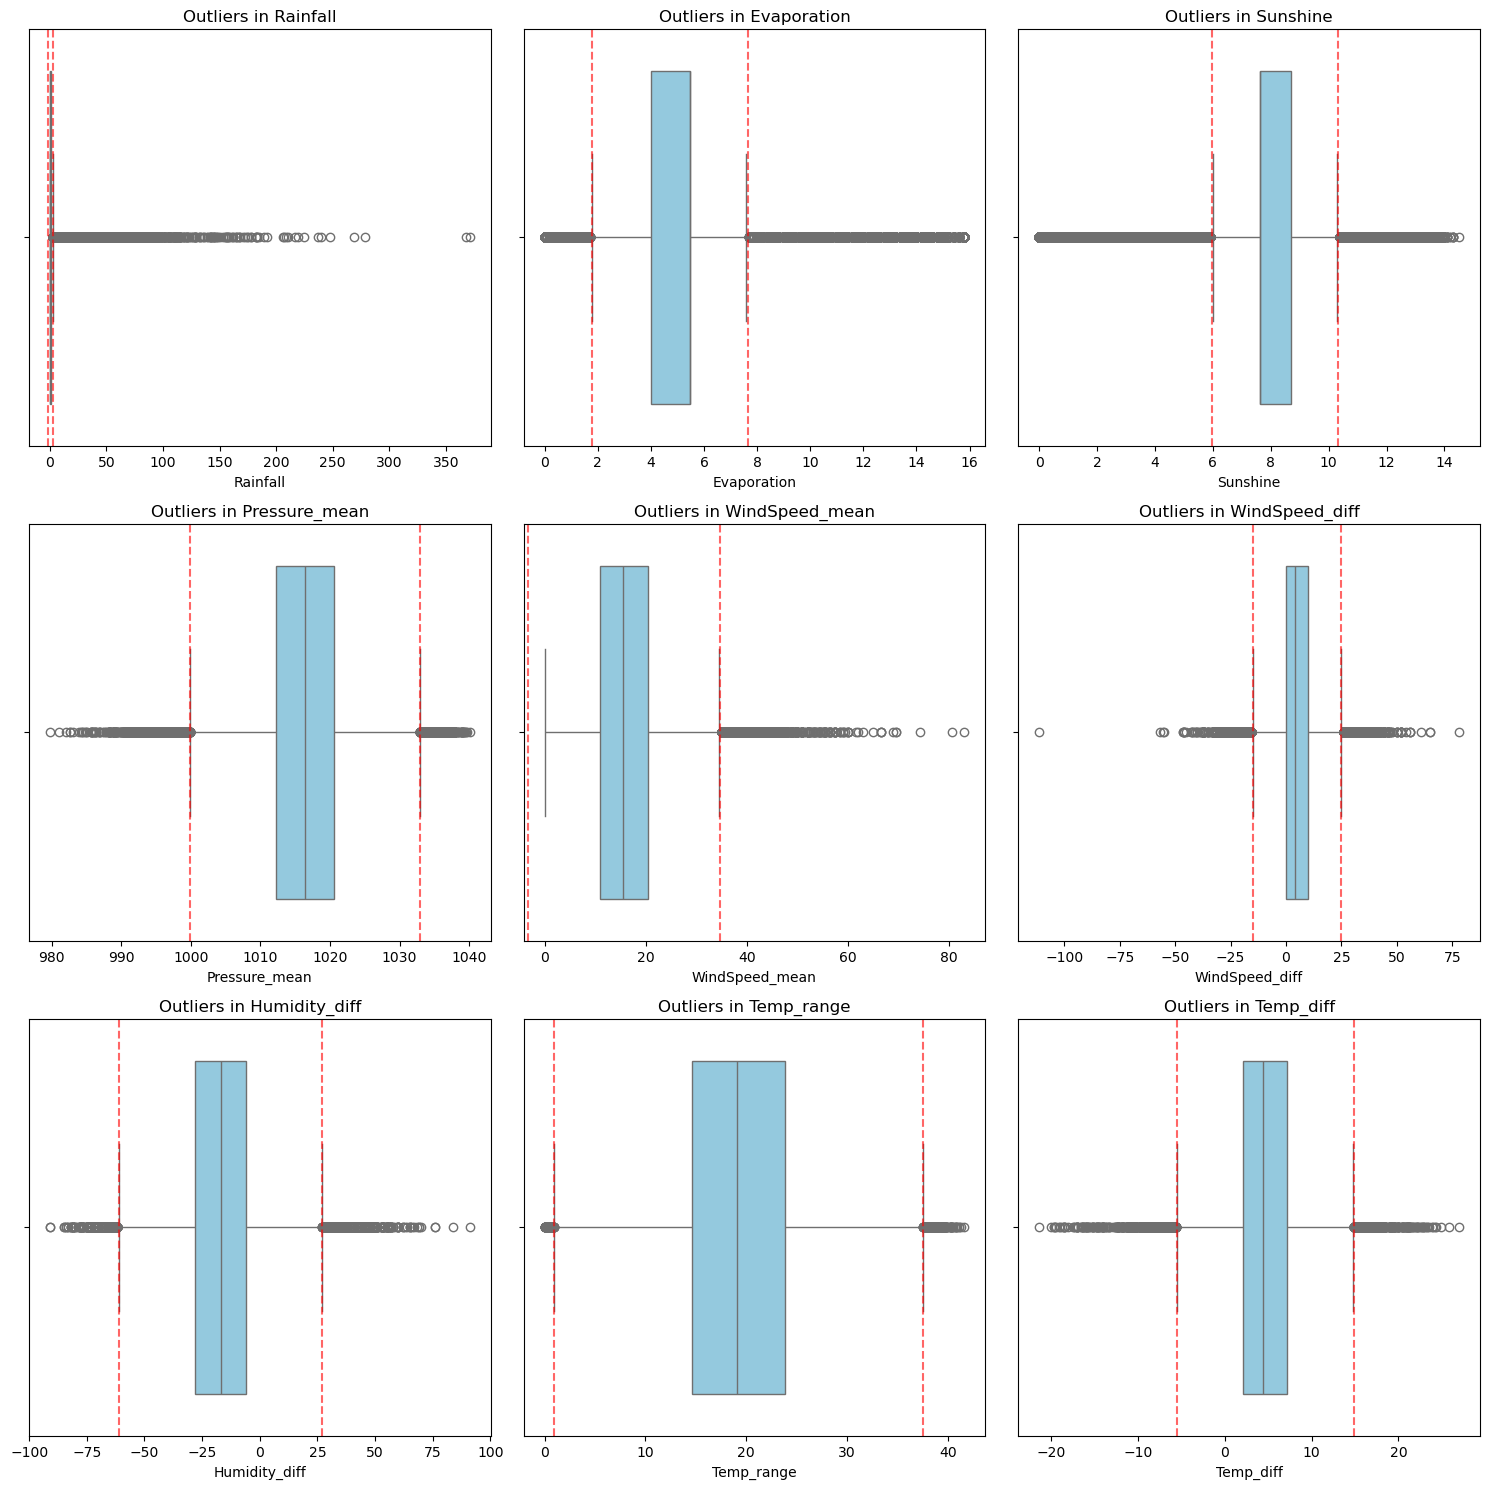

In [52]:
cols = ['Rainfall', 'Evaporation', 'Sunshine', 'Pressure_mean', 
        'WindSpeed_mean', 'WindSpeed_diff', 'Humidity_diff',
        'Temp_range', 'Temp_diff']

detector = OutlierDetector(df)
limits = detector.find_fences(columns=cols, plot=True)

In [53]:
df.drop_duplicates()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,RainTomorrow,Pressure_mean,Pressure_diff,WindSpeed_mean,...,Humidity_diff,Cloud_mean,Cloud_diff,Temp_range,Temp_diff,Month,WindDir9am_angle,WindDir3pm_angle,WindGustDir_angle,ClimateZone
0,10.8,21.2,0.0,1.80,6.60,22.0,0,1026.55,-3.7,8.0,...,-18.0,4.480,0.06,18.35,5.3,4,67.5,315.0,67.5,4
1,3.7,19.0,0.0,1.40,7.61,24.0,0,1022.65,-3.1,5.5,...,-43.0,4.480,0.06,14.05,8.9,7,0.0,22.5,0.0,4
2,9.6,15.8,0.0,2.60,7.61,52.0,1,1014.70,-6.4,14.5,...,16.0,4.480,0.06,15.05,0.7,7,22.5,45.0,45.0,4
3,10.1,15.5,16.6,0.80,7.61,50.0,1,1007.70,0.6,21.5,...,-16.0,4.480,0.06,12.60,2.8,7,315.0,315.0,22.5,4
4,11.2,16.2,1.8,0.60,7.61,30.0,1,1018.80,0.8,14.0,...,-19.0,4.480,0.06,14.15,2.3,7,292.5,292.5,315.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,16.8,31.9,0.0,15.80,7.61,44.0,0,1015.75,-3.1,23.0,...,-34.0,2.255,4.51,24.85,9.3,1,135.0,180.0,157.5,1
145456,17.0,33.5,0.0,12.40,12.70,43.0,0,1013.50,-3.4,20.5,...,-26.0,0.000,0.00,27.10,9.8,1,112.5,112.5,157.5,1
145457,18.9,38.8,0.0,12.00,12.40,41.0,0,1010.35,-3.3,20.0,...,-5.0,0.000,0.00,32.75,10.3,1,67.5,337.5,0.0,1
145458,23.5,38.3,0.0,15.80,13.00,50.0,0,1012.25,-1.9,15.5,...,-32.0,1.000,0.00,30.25,10.3,1,157.5,90.0,157.5,1


## Insights

Now our dataset is much clean and some extrieme values are realistic not randome so removing them will cause miss behave of the model. Now our data set is ready to train a model. 

In [54]:
# Export to csv file
# df.to_csv("processed.csv", index=False)

---
## Feature Engineering
Fine tuning featuers for improving accuracy, Extract feature or remove to improve accuracy.

In [55]:
df2 = pd.read_csv("../data/processed.csv")

In [56]:
df2.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,RainTomorrow,Pressure_mean,Pressure_diff,WindSpeed_mean,...,Humidity_diff,Cloud_mean,Cloud_diff,Temp_range,Temp_diff,Month,WindDir9am_angle,WindDir3pm_angle,WindGustDir_angle,ClimateZone
0,10.8,21.2,0.0,1.8,6.60,22.0,0,1026.55,-3.7,8.0,...,-18.0,4.48,0.06,18.35,5.3,4,67.5,315.0,67.5,4
1,3.7,19.0,0.0,1.4,7.61,24.0,0,1022.65,-3.1,5.5,...,-43.0,4.48,0.06,14.05,8.9,7,0.0,22.5,0.0,4
2,9.6,15.8,0.0,2.6,7.61,52.0,1,1014.70,-6.4,14.5,...,16.0,4.48,0.06,15.05,0.7,7,22.5,45.0,45.0,4
3,10.1,15.5,16.6,0.8,7.61,50.0,1,1007.70,0.6,21.5,...,-16.0,4.48,0.06,12.60,2.8,7,315.0,315.0,22.5,4
4,11.2,16.2,1.8,0.6,7.61,30.0,1,1018.80,0.8,14.0,...,-19.0,4.48,0.06,14.15,2.3,7,292.5,292.5,315.0,4


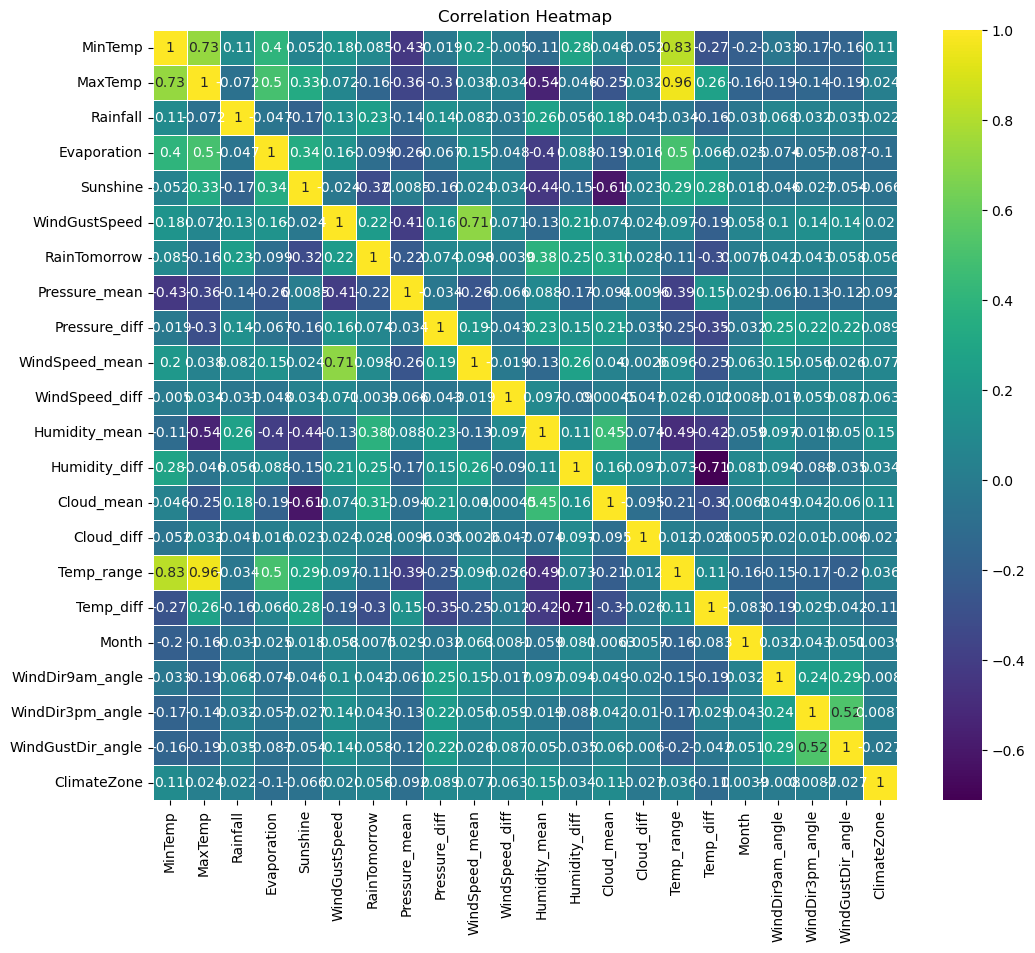

In [57]:
plt.figure(figsize=(12, 10))

corr = df2.corr()
sns.heatmap(corr, 
            annot=True,      # True will print numbers (can get messy)
            cmap='viridis',
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

### Featuers to remove
1. `Temp_deff`
2. `pressure_mean`
3. `sunshine`

In [58]:
df2.columns

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'RainTomorrow', 'Pressure_mean', 'Pressure_diff',
       'WindSpeed_mean', 'WindSpeed_diff', 'Humidity_mean', 'Humidity_diff',
       'Cloud_mean', 'Cloud_diff', 'Temp_range', 'Temp_diff', 'Month',
       'WindDir9am_angle', 'WindDir3pm_angle', 'WindGustDir_angle',
       'ClimateZone'],
      dtype='object')

In [59]:
# Removing featuers
data2 = df2.copy()

In [60]:
data2.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,RainTomorrow,Pressure_mean,Pressure_diff,WindSpeed_mean,...,Humidity_diff,Cloud_mean,Cloud_diff,Temp_range,Temp_diff,Month,WindDir9am_angle,WindDir3pm_angle,WindGustDir_angle,ClimateZone
0,10.8,21.2,0.0,1.8,6.60,22.0,0,1026.55,-3.7,8.0,...,-18.0,4.48,0.06,18.35,5.3,4,67.5,315.0,67.5,4
1,3.7,19.0,0.0,1.4,7.61,24.0,0,1022.65,-3.1,5.5,...,-43.0,4.48,0.06,14.05,8.9,7,0.0,22.5,0.0,4
2,9.6,15.8,0.0,2.6,7.61,52.0,1,1014.70,-6.4,14.5,...,16.0,4.48,0.06,15.05,0.7,7,22.5,45.0,45.0,4
3,10.1,15.5,16.6,0.8,7.61,50.0,1,1007.70,0.6,21.5,...,-16.0,4.48,0.06,12.60,2.8,7,315.0,315.0,22.5,4
4,11.2,16.2,1.8,0.6,7.61,30.0,1,1018.80,0.8,14.0,...,-19.0,4.48,0.06,14.15,2.3,7,292.5,292.5,315.0,4


In [61]:
data2.shape

(145230, 22)

In [62]:
data2.drop(columns=['Sunshine', 'Temp_diff', 'Pressure_mean'], inplace=True)

In [63]:
data2.shape

(145230, 19)

## Exporting data with some removed featuers
Removed `Temp_deff`, `pressure_mean`, & `sunshine` featuers.

In [65]:
# data2.to_csv('data2.csv', index = False)